# UMAP пример

In [10]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install -q umap-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np

In [13]:
# Загружаем датасет
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t5_sleep.csv")

In [14]:
# Фиксируем список признаков для работы
feature_cols = [
    "age",
    "marital-status",
    "gender",
    "bmi",
    "snoring-rate",
    "respiration-rate",
    "body-temperature",
    "limb-movement",
    "blood-oxygen",
    "eye-movement",
    "sleeping-hours",
    "heart-rate",
]

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Создаём копию, чтобы не менять исходный df
X = df[feature_cols].copy()

# Проверяем размер матрицы признаков: число объектов и признаков
print("X shape:", X.shape)

# Приводим все данные к числовому формату
# Если в файле все признаки уже содержат данные типа 0/1 и float, этот шаг ничего не испортит
# errors="coerce" превращает нечисловые значения в NaN
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Заполняем пропуски медианой по каждому столбцу
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Масштабируем признаки: после StandardScaler в каждом столбце будет среднее ~0 и std ~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Проверяем размер итоговой матрицы, которую будем передавать t-SNE
print("X_scaled shape:", X_scaled.shape)

X shape: (5000, 12)
X_scaled shape: (5000, 12)


In [16]:
from umap import UMAP

umap = UMAP(
    n_components=2, # выбираем 2D-координаты
    random_state=42, # фиксируем случайность для воспроизводимости
)

X_umap = umap.fit_transform(X_scaled)

umap_df = pd.DataFrame(X_umap, columns=["umap_1", "umap_2"])
umap_df.head()

/Users/a1/Desktop/learning/ml_for_newbie/unsupervised-learning-examples/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,umap_1,umap_2
0,9.438455,11.504868
1,7.231842,13.203454
2,12.060474,3.009548
3,-0.277501,-0.094218
4,7.361263,11.876922


Text(0.5, 0, 'umap_1')

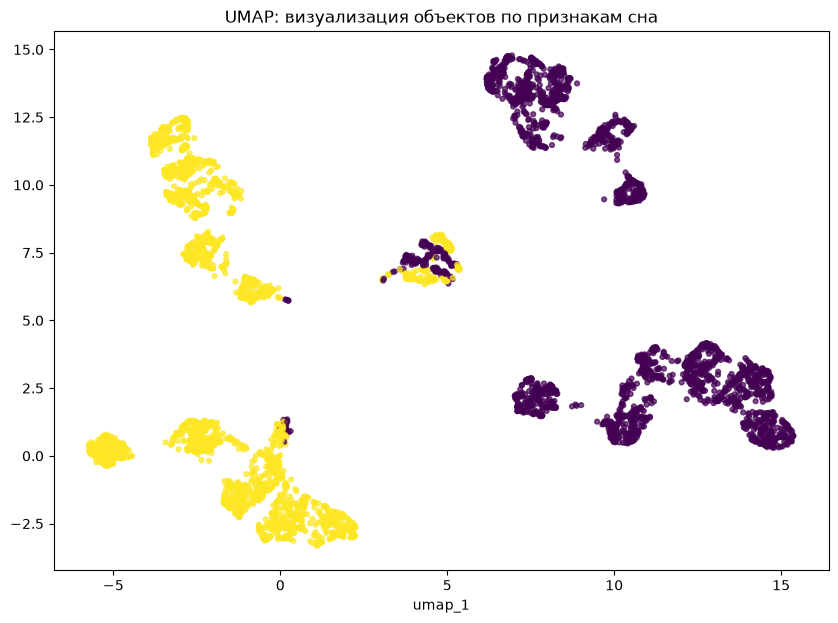

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    c=df["marital-status"],
    s=12,
    alpha=0.7,
)

plt.title("UMAP: визуализация объектов по признакам сна")
plt.xlabel("umap_1")

Text(0.5, 0, 'umap_1')

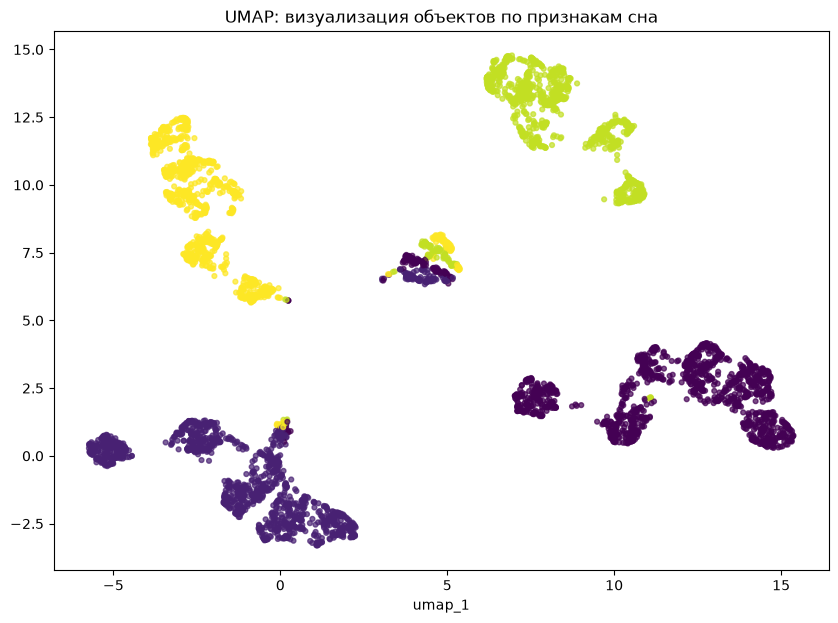

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    c=(df["gender"].astype(str) + df["marital-status"].astype(str)).astype(int),
    s=12,
    alpha=0.7
)

plt.title("UMAP: визуализация объектов по признакам сна")
plt.xlabel("umap_1")

Text(0.5, 0, 'umap_1')

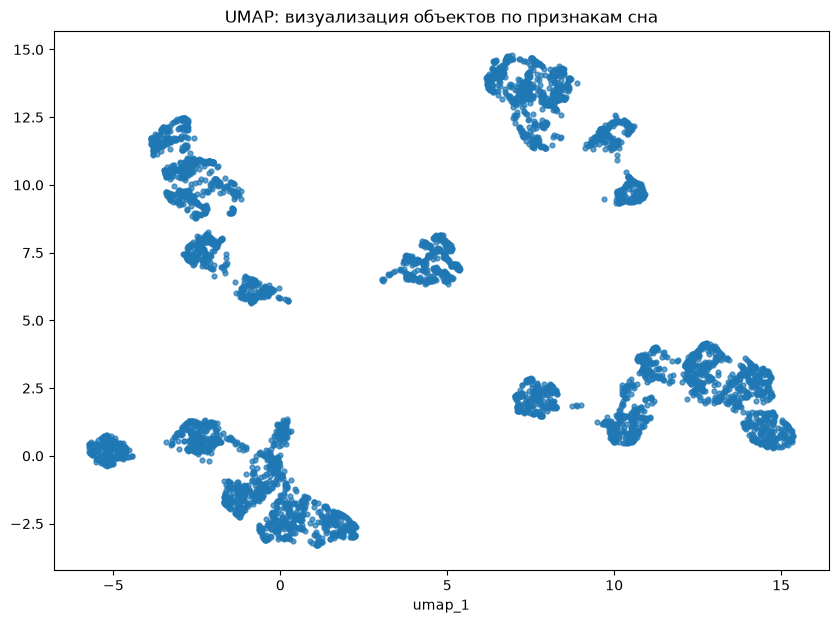

In [21]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    s=12,
    alpha=0.7,
)

plt.title("UMAP: визуализация объектов по признакам сна")
plt.xlabel("umap_1")

In [24]:
# Анализ групп
from sklearn.cluster import DBSCAN
labels = DBSCAN(eps=0.7, min_samples=15).fit_predict(umap_df)  # embedding = 2D UMAP
pd.Series(labels).value_counts()

2    1151
3    1110
4     948
1     613
7     394
0     337
5     238
6     209
Name: count, dtype: int64

Text(0.5, 0, 'umap_1')

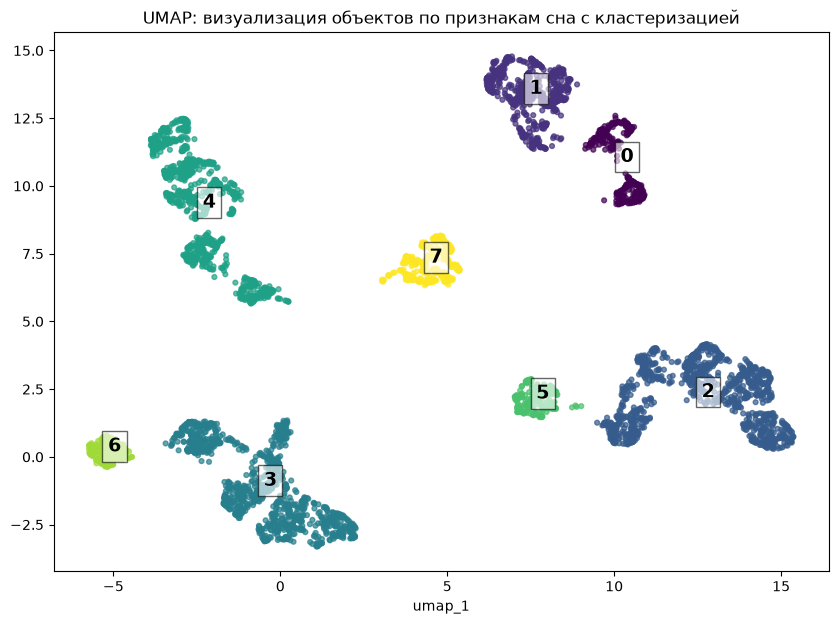

In [29]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    s=12,
    c=labels,
    alpha=0.7,
)

# Add label numbers at cluster centers
import numpy as np
for label in np.unique(labels):
    mask = labels == label
    x_mean = umap_df["umap_1"][mask].mean()
    y_mean = umap_df["umap_2"][mask].mean()
    plt.text(
        x_mean, y_mean, str(label),
        fontsize=14, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='black')
    )

plt.title("UMAP: визуализация объектов по признакам сна c кластеризацией")
plt.xlabel("umap_1")

In [43]:
X_labeld = pd.DataFrame(scaler.inverse_transform(X_scaled), columns=X.columns)
X_labeld["cluster"] = labels

X_labeld.groupby("cluster").mean().T

cluster,0,1,2,3,4,5,6,7
age,41.527122,42.478173,42.724518,43.514631,41.462785,44.549748,44.862775,43.525584
marital-status,0.000000,0.000000,0.000000,0.982883,0.994726,0.000000,1.000000,0.510152
gender,1.000000,1.000000,0.003475,0.018018,0.996835,0.000000,0.000000,0.431472
bmi,27.604415,26.999524,27.395930,27.271438,26.869466,28.433050,29.360574,29.153299
snoring-rate,17.750742,19.123980,19.263249,21.422523,21.529536,20.798319,21.124402,23.865482
respiration-rate,16.065282,16.207178,16.071242,16.584685,16.481013,16.289916,16.387560,16.350254
body-temperature,89.177739,93.452176,92.805371,92.654577,91.981561,87.466429,87.245024,92.256914
limb-movement,16.238030,9.308359,10.420455,10.445614,11.594608,17.821008,17.931177,11.680244
blood-oxygen,87.563822,93.574760,92.957143,91.958400,91.524515,84.672605,84.744995,91.050538
eye-movement,23.821958,23.386623,23.615117,23.530667,23.457806,23.592437,23.593301,88.430254


In [44]:
profile = X_labeld.groupby("cluster").mean(numeric_only=True)
z = (profile - X_labeld.drop(columns="cluster").mean()) / X_labeld.drop(columns="cluster").std()
z.T.round(2)

cluster,0,1,2,3,4,5,6,7
age,-0.06,-0.01,-0.00,0.03,-0.06,0.08,0.09,0.03
marital-status,-0.98,-0.98,-0.98,0.99,1.01,-0.98,1.02,0.04
gender,1.18,1.18,-0.84,-0.81,1.17,-0.85,-0.85,0.03
bmi,0.01,-0.07,-0.01,-0.03,-0.08,0.12,0.24,0.21
snoring-rate,-0.26,-0.13,-0.12,0.08,0.09,0.02,0.05,0.31
respiration-rate,-0.08,-0.04,-0.08,0.08,0.05,-0.01,0.02,0.01
body-temperature,-0.61,0.34,0.20,0.16,0.01,-1.00,-1.05,0.08
limb-movement,1.05,-0.54,-0.29,-0.28,-0.02,1.41,1.44,0.00
blood-oxygen,-0.85,0.52,0.38,0.15,0.05,-1.52,-1.50,-0.05
eye-movement,-0.27,-0.29,-0.28,-0.28,-0.29,-0.28,-0.28,3.31
